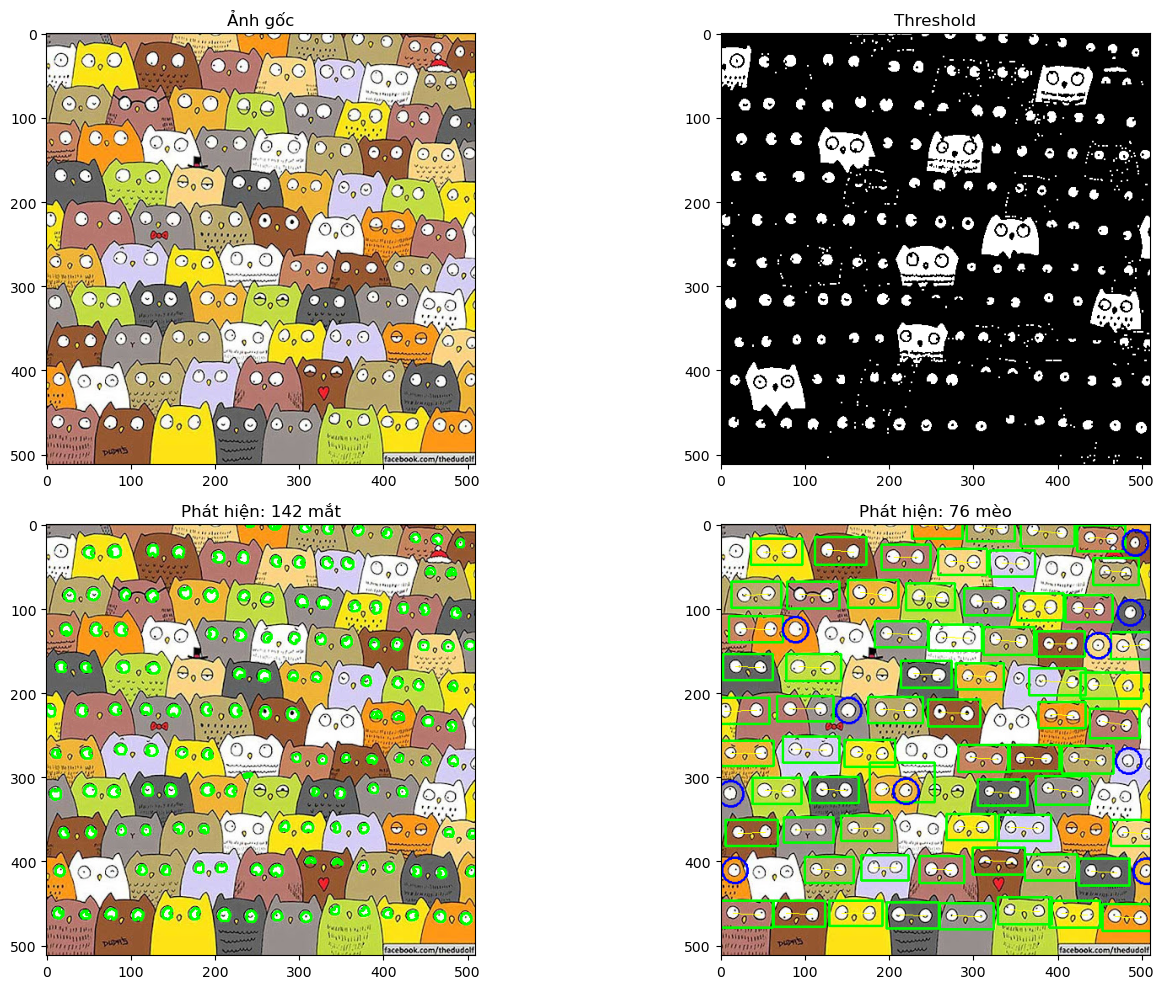

Số lượng mèo phát hiện được: 76


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_cats_eye_detection(image_path):
    image = cv2.imread(image_path)
    # if image is None:
    #     print(f"Không thể đọc ảnh từ {image_path}")
    #     return 0
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Chuyển sang ảnh xám
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Áp dụng thresholding để tách mắt (màu trắng trên nền tối)
    _, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)
    # _, thresh = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY_INV)
    
    # Lọc nhiễu
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Tìm contours của mắt
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Lọc contours dựa trên hình dạng (gần tròn) và kích thước
    min_area = 13  # Min
    max_area = 250  # Max
    eye_contours = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            # Kiểm tra tính tròn của contour - giảm ngưỡng để linh hoạt hơn
            perimeter = cv2.arcLength(cnt, True)
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter * perimeter)
                if circularity > 0.35:  # Ngưỡng tròn hạ xuống (1 = hoàn toàn tròn)
                    eye_contours.append(cnt)
    
    # Vẽ contours mắt
    eye_image = image_rgb.copy()
    cv2.drawContours(eye_image, eye_contours, -1, (0, 255, 0), 2)
    
    # Lấy tâm của mỗi mắt
    eye_centers = []
    for cnt in eye_contours:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            eye_centers.append((cx, cy))
    
    # Nhóm các mắt theo cặp dựa trên khoảng cách và vị trí tương đối
    max_dist = 70  # Khoảng cách tối đa giữa hai mắt - tăng để bắt được mèo lớn hơn     
    paired_eyes = []
    unpaired_eyes = eye_centers.copy()
    
    # Sắp xếp mắt từ trên xuống dưới, từ trái sang phải
    unpaired_eyes.sort(key=lambda p: (p[1], p[0]))
    
    while len(unpaired_eyes) > 1:
        eye1 = unpaired_eyes[0]
        unpaired_eyes.remove(eye1)
        
        found_pair = False
        best_pair = None
        min_distance = float('inf')
        
        # Tìm mắt thứ 2 gần nhất và phù hợp nhất
        for eye2 in unpaired_eyes:
            dx = abs(eye1[0] - eye2[0])
            dy = abs(eye1[1] - eye2[1])
            
            # Tính khoảng cách Euclidean
            distance = np.sqrt(dx*dx + dy*dy)
            
            # Mắt của một mèo thường:
            # 1. Cách nhau theo chiều ngang nhiều hơn theo chiều dọc
            # 2. Gần nhau theo khoảng cách tổng thể
            # 3. Nằm gần như cùng một hàng ngang (dy nhỏ)
            if distance < max_dist and dx > dy and dy < max_dist/3:
                # Chọn cặp mắt có khoảng cách gần nhau nhất
                if distance < min_distance:
                    min_distance = distance
                    best_pair = eye2
        
        # Nếu tìm thấy cặp tốt nhất
        if best_pair:
            paired_eyes.append((eye1, best_pair))
            unpaired_eyes.remove(best_pair)
            found_pair = True
        
        # Nếu không tìm thấy cặp, coi đây là mèo có một mắt (hoặc mắt thứ hai không được phát hiện)
        if not found_pair:
            paired_eyes.append((eye1,))
    
    # Thêm mắt lẻ còn lại (nếu có)
    if unpaired_eyes:
        for eye in unpaired_eyes:
            paired_eyes.append((eye,))
    
    # Mỗi cặp mắt tương ứng với một con mèo
    cat_count = len(paired_eyes)
    
    # Vẽ hình chữ nhật quanh mỗi mèo
    cat_image = image_rgb.copy()
    for pair in paired_eyes:
        if len(pair) == 2:
            # Tìm hình chữ nhật bao quanh cặp mắt
            x1, y1 = pair[0]
            x2, y2 = pair[1]
            x = min(x1, x2) - 15
            y = min(y1, y2) - 15
            w = abs(x2 - x1) + 30  # Mở rộng để bao trọn khuôn mặt mèo
            h = abs(y2 - y1) + 30
            
            # Vẽ hình chữ nhật xanh lá cho mèo có 2 mắt
            cv2.rectangle(cat_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Vẽ đường nối 2 mắt
            cv2.line(cat_image, pair[0], pair[1], (255, 255, 0), 1)
        else:
            # Trường hợp chỉ có một mắt - vẽ vòng tròn màu xanh dương
            x, y = pair[0]
            cv2.circle(cat_image, (x, y), 15, (0, 0, 255), 2)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    plt.subplot(221), plt.imshow(image_rgb), plt.title('Ảnh gốc')
    plt.subplot(222), plt.imshow(thresh, cmap='gray'), plt.title('Threshold')
    plt.subplot(223), plt.imshow(eye_image), plt.title(f'Phát hiện: {len(eye_contours)} mắt')
    plt.subplot(224), plt.imshow(cat_image), plt.title(f'Phát hiện: {cat_count} mèo')
    plt.tight_layout()
    plt.show()
    
    return cat_count, paired_eyes

# Nếu muốn thực thi trực tiếp
if __name__ == "__main__":
    image_path = "couting/cat.jpg"  # Thay bằng đường dẫn thực tế đến ảnh
    count, pairs = count_cats_eye_detection(image_path)
    print(f"Số lượng mèo phát hiện được: {count}")

Các diện tích đã phát hiện: [   9    9   10   12   12   15   22   31   47   49   51   52   53   53
   56   57   60   68   71   72   74   75   78   80   81   82   82   83
   83   84   84   86   86   88   88   88   89   92   92   94   95   97
   97   97   98   99   99   99  100  100  101  101  101  102  102  103
  105  105  106  106  106  106  107  107  108  108  108  109  109  109
  109  109  110  111  111  112  112  112  114  116  116  116  116  116
  118  118  119  120  121  122  124  124  125  125  127  128  130  134
  135  136  136  138  138  138  140  140  141  141  142  143  143  148
  149  150  150  151  151  151  152  153  154  154  154  154  157  157
  158  158  161  162  163  164  164  167  167  168  169  171  175  179
  181  185  187  189  202  214  568 1833 2369 2667 2861 2891 3107 3276
 3562 3915]


[ WARN:0@6197.213] global /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_11nitadzeg/croot/opencv-suite_1691620374638/work/modules/imgcodecs/src/loadsave.cpp (239) findDecoder imread_('couting/original.png'): can't open/read file: check file path/integrity


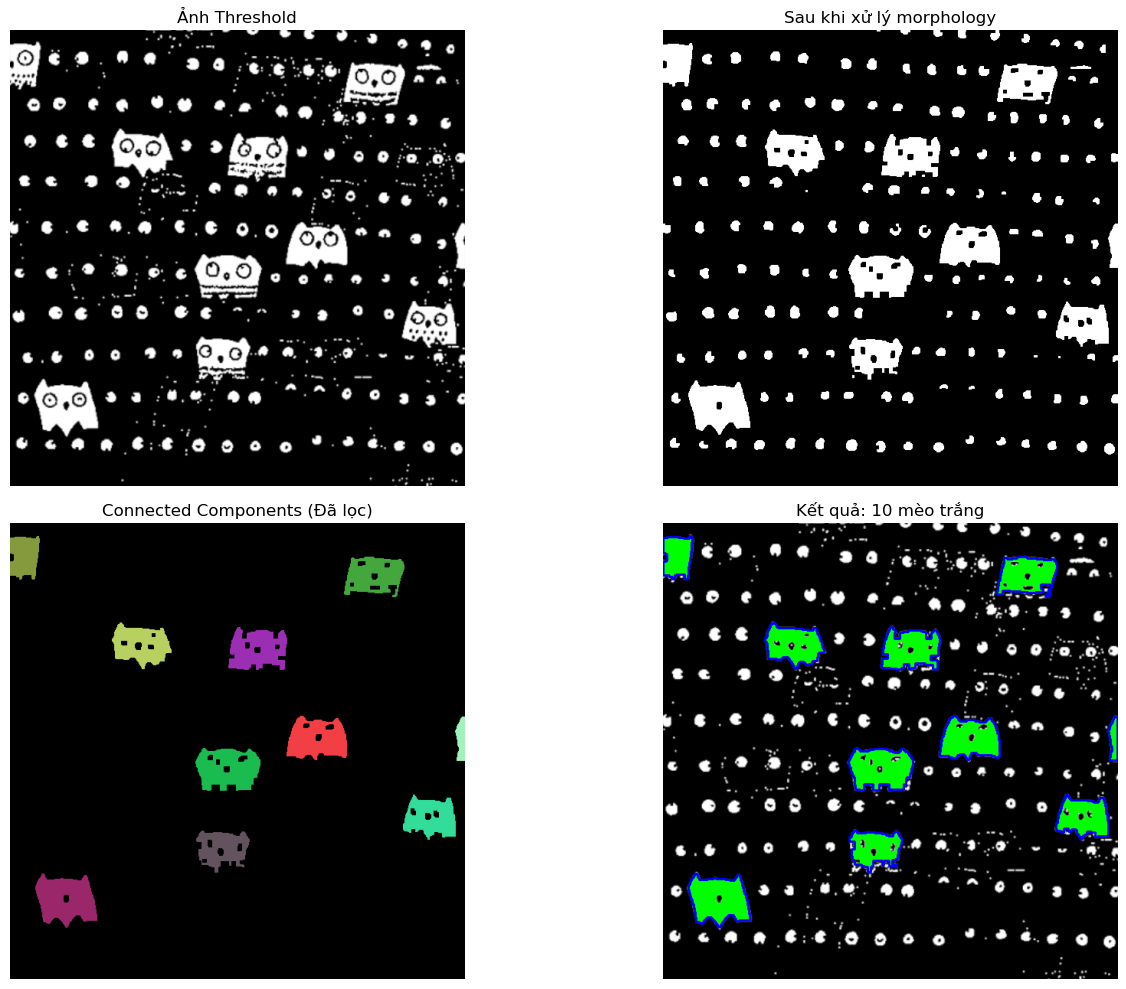

Tổng số connected components: 156
Số lượng mèo trắng: 10


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_white_cats(threshold_image_path):
    # Đọc ảnh threshold
    img = cv2.imread(threshold_image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Không thể đọc ảnh từ {threshold_image_path}")
        return 0, None
    
    # Đảm bảo ảnh là nhị phân (đen trắng)
    _, binary = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)
    
    # Xóa nhiễu nhỏ bằng phép toán open (erode rồi dilate)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Kết nối các thành phần bị gián đoạn bằng phép toán close (dilate rồi erode)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Tìm các connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closing, connectivity=8)
    
    # Lọc các connected components dựa trên kích thước
    # stats[label, cv2.CC_STAT_AREA] cho diện tích của mỗi connected component
    
    # Tính diện tích trung bình của các mèo (loại bỏ background có label=0)
    areas = stats[1:, cv2.CC_STAT_AREA]  # Bỏ qua background
    
    # Sắp xếp diện tích để phân tích
    sorted_areas = np.sort(areas)
    
    # In thông tin để kiểm tra
    print(f"Các diện tích đã phát hiện: {sorted_areas}")
    
    # Đếm số lượng mèo trắng (connected components có diện tích >= area_threshold)
    white_cat_count = np.sum(areas >= 500)
    
    # Tạo ảnh kết quả với màu sắc để trực quan hóa
    white_cats_mask = np.zeros_like(labels, dtype=np.uint8)
    
    # Tô các mèo trắng vào mask
    for label in range(1, num_labels):  # Bỏ qua background (label=0)
        if stats[label, cv2.CC_STAT_AREA] >= 500:
            white_cats_mask[labels == label] = 255
    
    # Tạo ảnh kết quả với các mèo trắng được đánh dấu
    # Đọc ảnh gốc nếu có để hiển thị kết quả
    try:
        original_img = cv2.imread(threshold_image_path.replace("threshold", "original"), cv2.IMREAD_COLOR)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    except:
        # Nếu không có ảnh gốc, sử dụng ảnh đen trắng
        original_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # Tạo mask màu để đánh dấu các mèo trắng
    color_mask = np.zeros_like(original_img)
    color_mask[:, :, 0] = 0    # Red channel
    color_mask[:, :, 1] = 255  # Green channel - Sử dụng màu xanh lá
    color_mask[:, :, 2] = 0    # Blue channel
    
    # Tạo ảnh kết quả với các mèo trắng được đánh dấu
    result_img = original_img.copy()
    result_img[white_cats_mask == 255] = color_mask[white_cats_mask == 255]
    
    # Vẽ viền xung quanh các connected component
    contours, _ = cv2.findContours(white_cats_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(result_img, contours, -1, (0, 0, 255), 2)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh Threshold')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(closing, cmap='gray')
    plt.title('Sau khi xử lý morphology')
    plt.axis('off')
    
    # Hiển thị ảnh với các connected component được gán nhãn
    plt.subplot(2, 2, 3)
    # Tạo ảnh nhãn màu sắc
    label_rgb = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= 500:
            # Tạo màu ngẫu nhiên cho mỗi label
            color = np.random.randint(0, 256, size=3)
            label_rgb[labels == label] = color
    plt.imshow(label_rgb)
    plt.title('Connected Components (Đã lọc)')
    plt.axis('off')
    
    plt.subplot(2, 2, 4)
    plt.imshow(result_img)
    plt.title(f'Kết quả: {white_cat_count} mèo trắng')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Hiển thị thêm thông tin chi tiết về các connected component
    print(f"Tổng số connected components: {num_labels-1}")
    print(f"Số lượng mèo trắng: {white_cat_count}")
    
    # Trả về số lượng mèo trắng và ảnh kết quả
    return white_cat_count, result_img

# Sử dụng hàm
white_cat_count, result = count_white_cats('couting/threshold.png')
# print(f"Số lượng mèo trắng: {white_cat_count}")

In [ ]:
result = 